In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
matches= pd.read_csv('matches.csv')
deliveries= pd.read_csv('deliveries.csv')

#### Basic Exploration

In [3]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


#### Dataset info and Data cleaning

In [5]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method           21 non-n

In [6]:
deliveries.info()

<class 'pandas.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   match_id          260920 non-null  int64
 1   inning            260920 non-null  int64
 2   batting_team      260920 non-null  str  
 3   bowling_team      260920 non-null  str  
 4   over              260920 non-null  int64
 5   ball              260920 non-null  int64
 6   batter            260920 non-null  str  
 7   bowler            260920 non-null  str  
 8   non_striker       260920 non-null  str  
 9   batsman_runs      260920 non-null  int64
 10  extra_runs        260920 non-null  int64
 11  total_runs        260920 non-null  int64
 12  extras_type       14125 non-null   str  
 13  is_wicket         260920 non-null  int64
 14  player_dismissed  12950 non-null   str  
 15  dismissal_kind    12950 non-null   str  
 16  fielder           9354 non-null    str  
dtypes: int64(8), str(9)
m

In [7]:
matches.drop('id', axis= 1, inplace = True)
deliveries.drop('match_id', axis=1, inplace= True)

In [8]:
matches.shape, deliveries.shape

((1095, 19), (260920, 16))

#### Handling missing values:

In [9]:
matches.isnull().sum()

season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [25]:
categorical = matches.select_dtypes(include='object').columns.tolist()
numerical = matches.select_dtypes(exclude='object').columns.tolist()

C:\Users\KHIM SINGH\AppData\Local\Temp\ipykernel_7080\3125378551.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = matches.select_dtypes(include='object').columns.tolist()


In [11]:
numerical

['result_margin', 'target_runs', 'target_overs']

In [12]:
categorical

['season',
 'city',
 'date',
 'match_type',
 'player_of_match',
 'venue',
 'team1',
 'team2',
 'toss_winner',
 'toss_decision',
 'winner',
 'result',
 'super_over',
 'method',
 'umpire1',
 'umpire2']

In [13]:
for col in categorical:
    matches[col]= matches[col].fillna(matches[col].mode()[0])

In [14]:
for col in numerical:
    matches[col]= matches[col].fillna(matches[col].mean())

In [15]:
matches.isnull().sum()

season             0
city               0
date               0
match_type         0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
target_runs        0
target_overs       0
super_over         0
method             0
umpire1            0
umpire2            0
dtype: int64

In [16]:
deliveries.isnull().sum()

inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [17]:
categorical = deliveries.select_dtypes(include='object').columns.tolist()
numerical = deliveries.select_dtypes(exclude='object').columns.tolist()

C:\Users\KHIM SINGH\AppData\Local\Temp\ipykernel_7080\767800845.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = deliveries.select_dtypes(include='object').columns.tolist()


In [18]:
categorical

['batting_team',
 'bowling_team',
 'batter',
 'bowler',
 'non_striker',
 'extras_type',
 'player_dismissed',
 'dismissal_kind',
 'fielder']

In [19]:
for col in categorical:
    deliveries[col]= deliveries[col].fillna(deliveries[col].mode()[0])

In [20]:
deliveries.isnull().sum()

inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batter              0
bowler              0
non_striker         0
batsman_runs        0
extra_runs          0
total_runs          0
extras_type         0
is_wicket           0
player_dismissed    0
dismissal_kind      0
fielder             0
dtype: int64

In [21]:
matches.duplicated().sum()

np.int64(0)

In [22]:
deliveries.duplicated().sum()

np.int64(624)

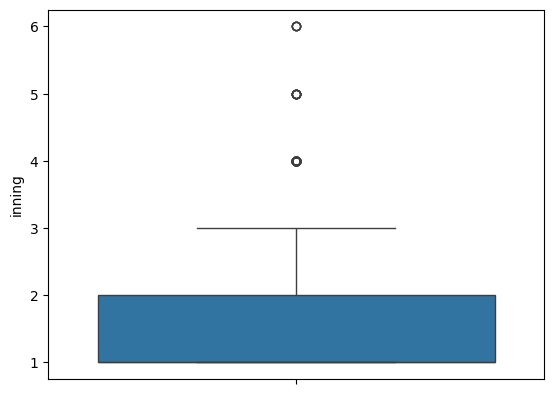

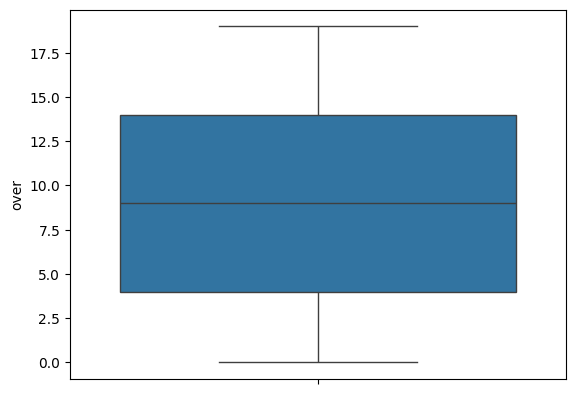

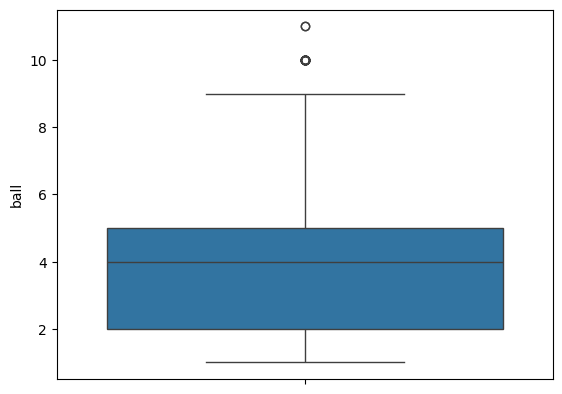

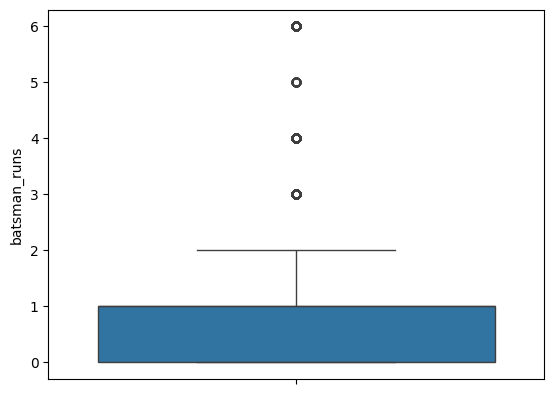

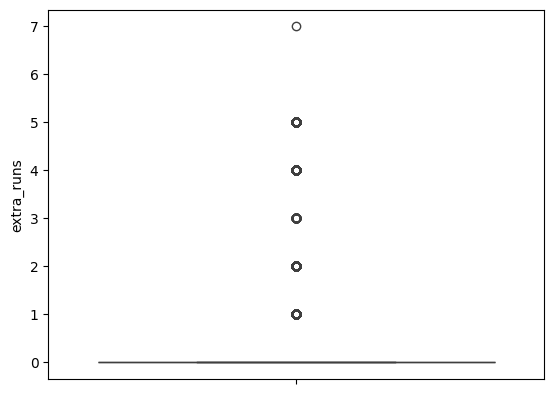

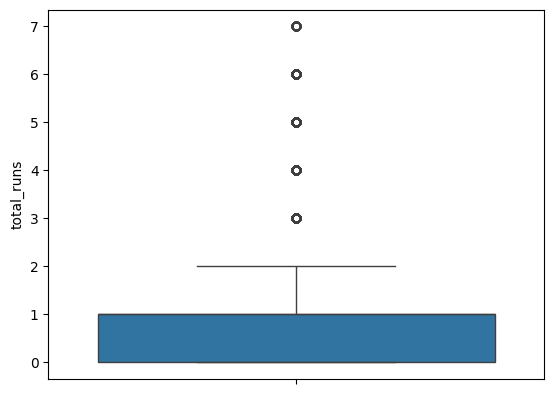

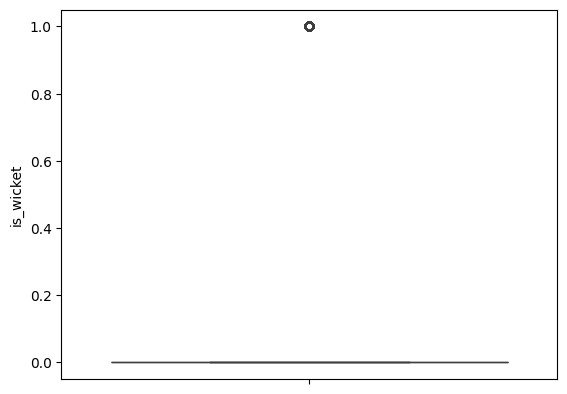

In [23]:
for col in numerical:
    plt.figure()
    sns.boxplot(deliveries[col])
    plt.show()

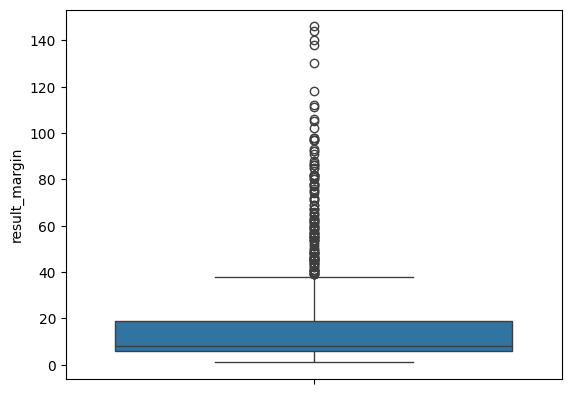

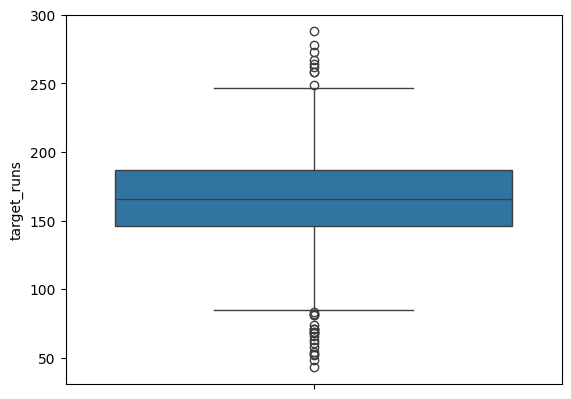

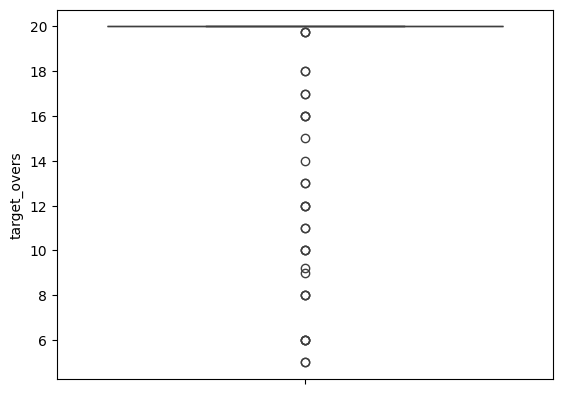

In [26]:
for i in numerical:
    plt.Figure()
    sns.boxplot(matches[i])
    plt.show()

In [27]:
matches.columns

Index(['season', 'city', 'date', 'match_type', 'player_of_match', 'venue',
       'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result',
       'result_margin', 'target_runs', 'target_overs', 'super_over', 'method',
       'umpire1', 'umpire2'],
      dtype='str')

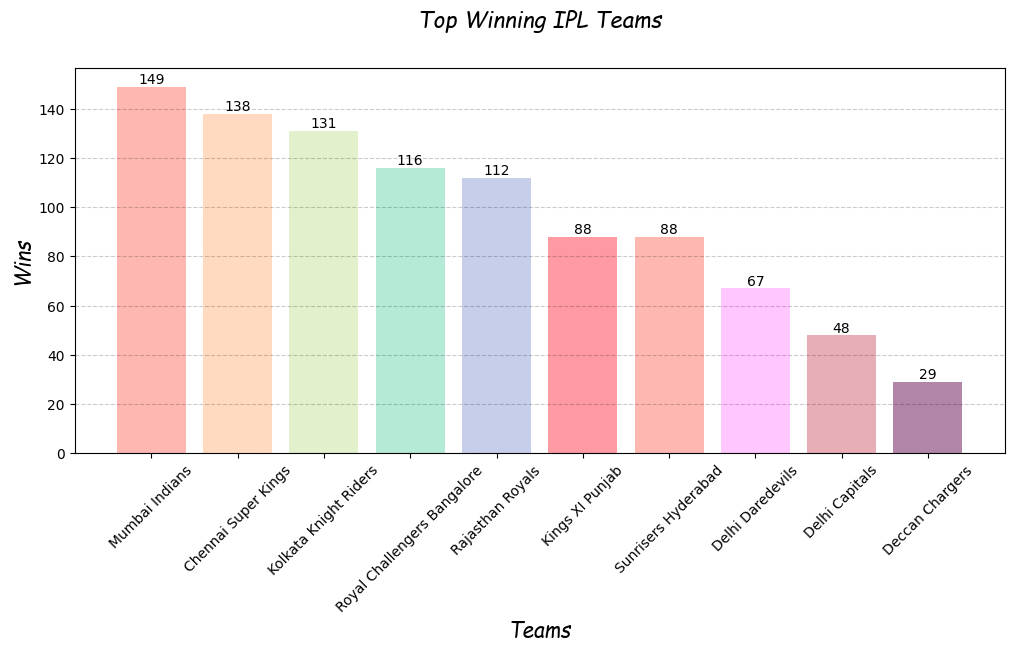

In [ ]:
# top winning ipl team
top_winner= matches['winner'].value_counts().head(10)

plt.figure(figsize=(12,5))
colours = ['#FFB7B2', '#FFDAC1', '#E2F0CB',
            '#B5EAD7', '#C7CEEA', '#FF9AA2',
              '#FFB7B2', '#FFC6FF', '#E8AEB7', '#B185A7']
plt.bar(top_winner.index, top_winner.values, color= colours)
font_dict = { 'color' : 'black',
              'family' :'cursive',
              'style'  : 'oblique',
              'size'  : 15}

for i in range(0, len(top_winner.values)):
    plt.annotate(xy = (i, top_winner.values[i]), text = top_winner.values[i], 
                ha = 'center',
                va = 'bottom',
                size = 10)
plt.title("Top Winning IPL Teams", fontsize=16, pad = 30, fontdict = font_dict)
plt.xlabel("Teams", fontdict = font_dict)
plt.ylabel("Wins", fontdict = font_dict)
plt.grid(axis = 'y', color = 'black' , alpha = 0.2, linestyle = 'dashed')
plt.xticks(rotation=45)
plt.savefig("images/top_teams.png")
plt.show()

Insight:

Mumbai Indians and Chennai Super Kings are among the most successful teams in IPL history with the highest number of wins.

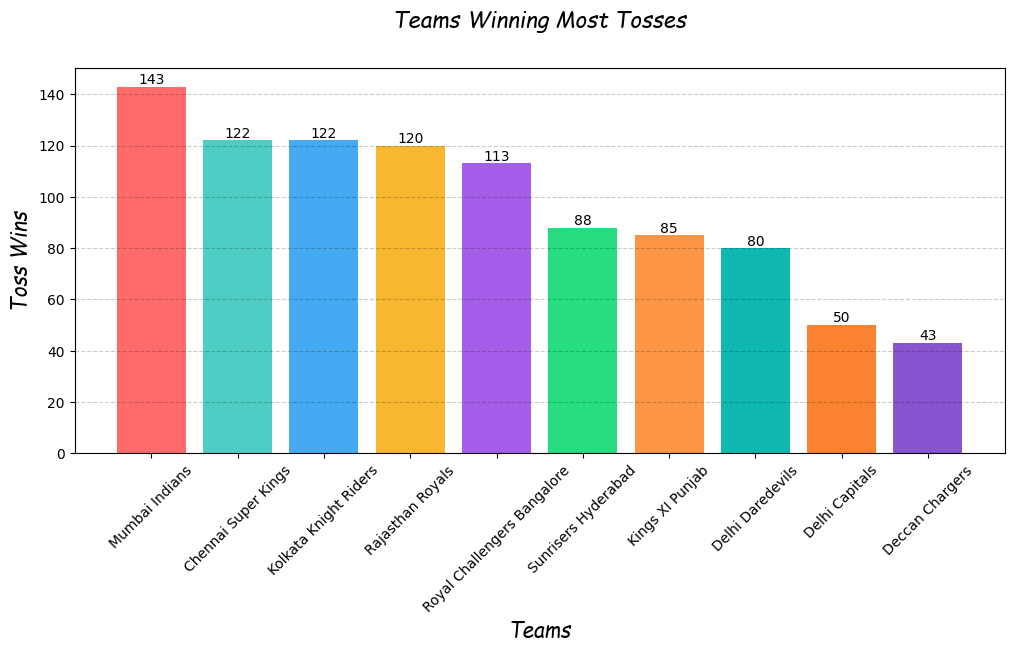

In [ ]:
# team winning most toss
toss = matches['toss_winner'].value_counts().head(10)

plt.figure(figsize=(12,5))
colours = ['#FF6B6B', '#4ECDC4', '#45AAF2',
            '#F7B731', '#A55EEA', '#26DE81',
              '#FD9644', '#0FB9B1', '#FA8231', '#8854D0']
plt.bar(toss.index, toss.values, color= colours)
font_dict = { 'color' : 'black',
              'family' :'cursive',
              'style'  : 'oblique',
              'size'  : 15}

for i in range(0, len(toss.values)):
    plt.annotate(xy = (i, toss.values[i]), text = toss.values[i], 
                ha = 'center',
                va = 'bottom',
                size = 10)

plt.title("Teams Winning Most Tosses", fontsize=16, pad = 30, fontdict = font_dict)
plt.xlabel("Teams", fontdict = font_dict)
plt.ylabel("Toss Wins", fontdict = font_dict)
plt.grid(axis = 'y', color = 'black' , alpha = 0.2, linestyle = 'dashed')
plt.xticks(rotation=45)
plt.savefig("images/toss_winners.png")
plt.show()

Insight:

Mumbai Indians and Chennai Super Kings are among the most successful teams in IPL history with the highest number of toss wining.

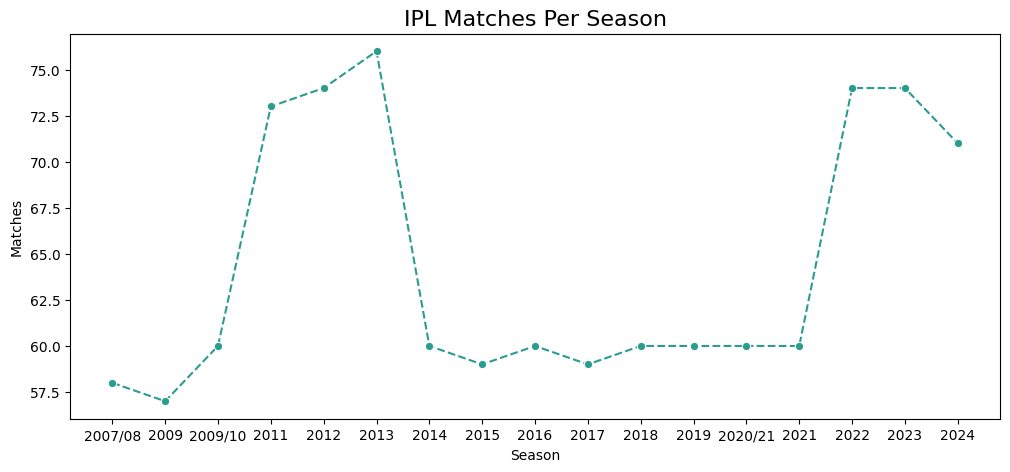

In [78]:
# ipl_matches per season
season_matches = matches['season'].value_counts().sort_index()

plt.figure(figsize=(12,5))

sns.lineplot(
    x=season_matches.index,
    y=season_matches.values,
    ls= 'dashed',
    marker='o',
    color= '#2A9D8F'
)

plt.title("IPL Matches Per Season", fontsize=16)
plt.xlabel("Season")
plt.ylabel("Matches")
plt.savefig("images/matches_per_season.png")

plt.show()

Insight:

The number of IPL matches increased over the years, showing the growth and popularity of the tournament.

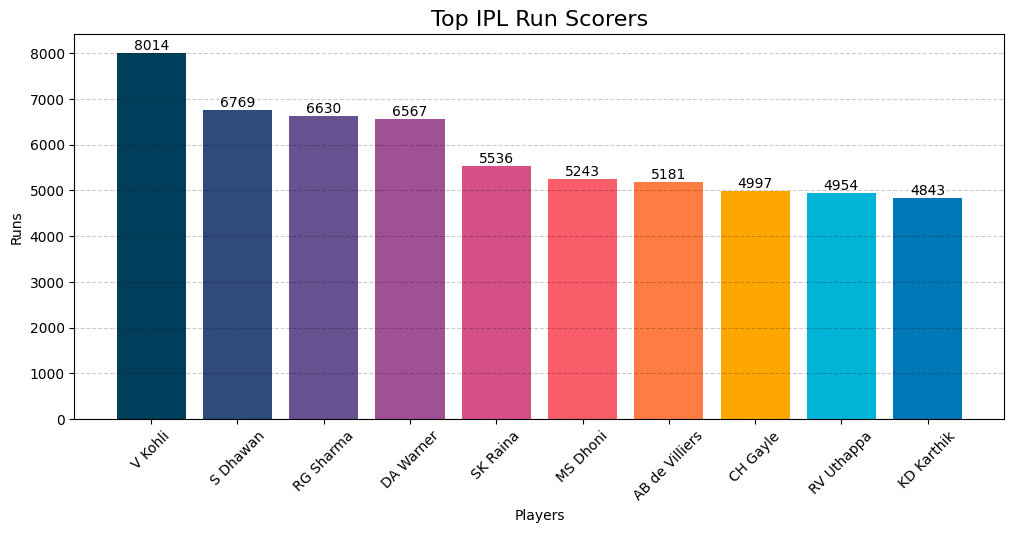

In [ ]:
# top run scorers
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum()
top_batsmen = top_batsmen.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
colours= ['#003F5C', '#2F4B7C', '#665191',
           '#A05195', '#D45087', '#F95D6A',
             '#FF7C43', '#FFA600', '#00B4D8', '#0077B6']
plt.bar(top_batsmen.index,top_batsmen.values, color= colours)

for i in range(0, len(top_batsmen.values)):
    plt.annotate(xy = (i, top_batsmen.values[i]), text = top_batsmen.values[i], 
                ha = 'center',
                va = 'bottom',
                size = 10)

plt.title("Top IPL Run Scorers", fontsize=16)
plt.xlabel("Players")
plt.ylabel("Runs")
plt.grid(axis = 'y', color = 'black' , alpha = 0.2, linestyle = 'dashed')
plt.xticks(rotation=45)
plt.savefig("images/top_batsmen.png")

plt.show()

Insight:

Top batsmen consistently contributed large numbers of runs across multiple IPL seasons, showing long-term performance stability.

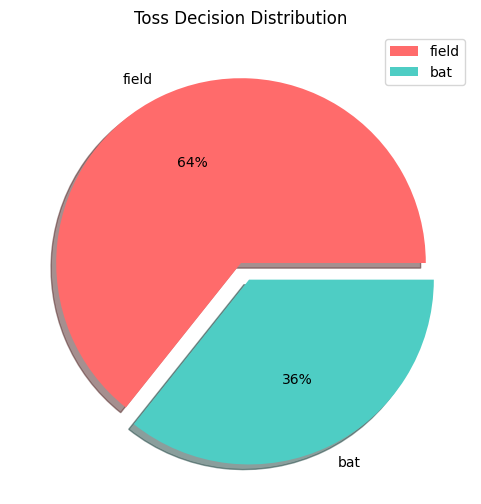

In [59]:
# toss decision distribution
decision = matches['toss_decision'].value_counts()

plt.figure(figsize=(6,6))

color= ['#FF6B6B', '#4ECDC4']
plt.pie(decision.values, 
        labels = decision.index,
        autopct = '%1.0f%%',
        startangle = 360,
        colors= color,
        explode = [0 , 0.1],
       shadow = True)

plt.legend(loc= ('upper right'))
plt.title("Toss Decision Distribution")
plt.savefig("images/toss_decision.png")
plt.show()

Insight:

Most teams prefer to field first after winning the toss, indicating a strong chasing strategy in IPL matches.

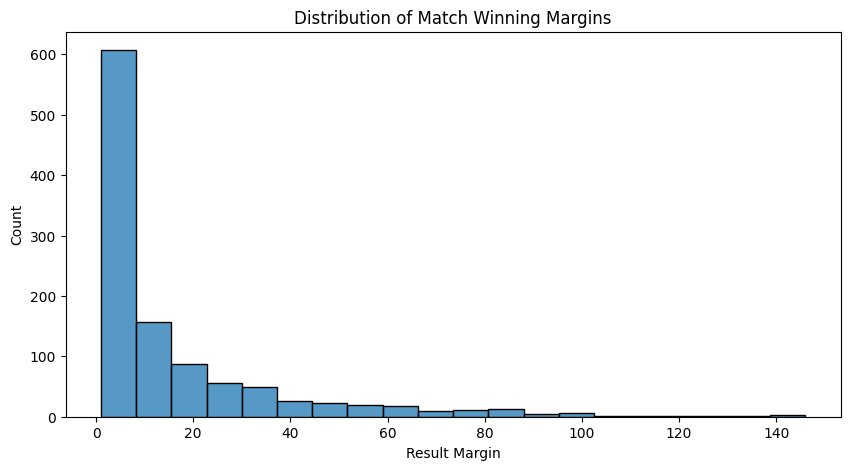

In [62]:
# distribution of match wining margins
plt.figure(figsize=(10,5))

sns.histplot(matches['result_margin'], bins=20,)
plt.title("Distribution of Match Winning Margins")
plt.xlabel("Result Margin")
plt.savefig("images/win_distribution.png")

plt.show()

Insight:

Most IPL matches are won by small to moderate margins, while extremely high winning margins are less common.

C:\Users\KHIM SINGH\AppData\Local\Temp\ipykernel_7080\122305294.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  decision_count = sns.countplot(x='toss_decision', data=matches,


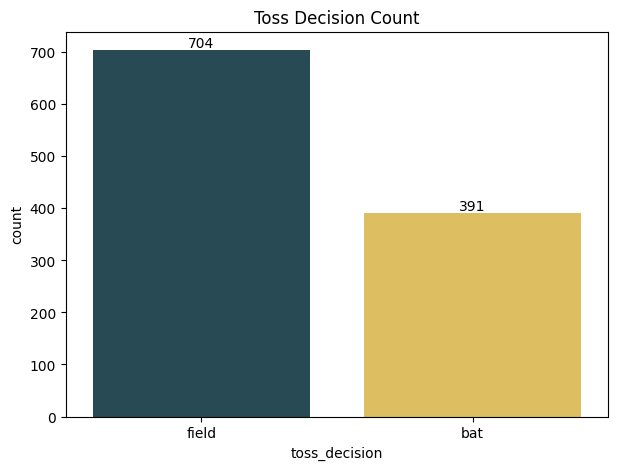

In [67]:
# toss decision count
plt.figure(figsize=(7,5))
colors= ['#1F4E5B', '#F2C94C']
decision_count = sns.countplot(x='toss_decision', data=matches,
                               palette= colors)
plt.title("Toss Decision Count")

for container in decision_count.containers:
    decision_count.bar_label(container)

plt.savefig("images/toss_count.png")

plt.show()

Insight:

Fielding after winning the toss is more common than batting first in IPL matches.

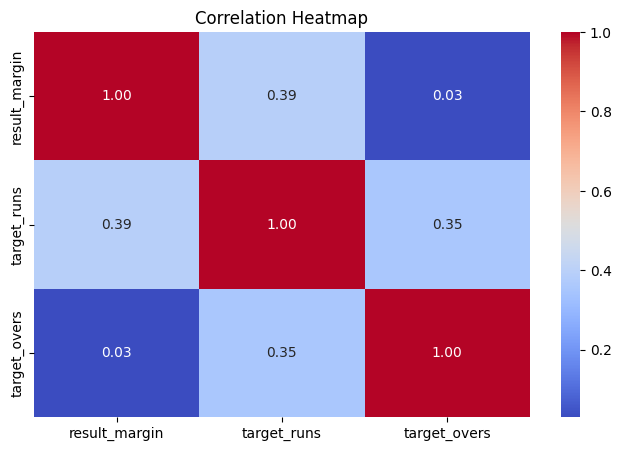

In [39]:
plt.figure(figsize=(8,5))

sns.heatmap(
    
    matches[numerical].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.savefig("images/heatmap.png")
plt.show()

Insight:

A moderate positive correlation exists between target_runs and result_margin, while target_overs has very weak correlation with match margins.

# Final Conclusion

- IPL has grown significantly over the years.
- Certain teams and players have consistently dominated the tournament.
- Toss decisions influence match strategies.
- Batting and bowling performances strongly impact match outcomes.
- Data visualization helps uncover meaningful trends and patterns in IPL history.